# e1_64x64_4_layered_no_aug_SGD

This is the baseline experiment. It includes following components in the model:
* 64x64x3 input size
* 4 Convolutional Layers
* Pooling Layer after each convolutional Layer
* SGD optimizer

### Importing required modules
Importing basic modules for training:
* torch
* datasets and transform
* dataloader

Importing Architecture:
* Architecture

Importing custom utils
* Trainer
* tester
* gen_line_charts

In [1]:
# torch and modules
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Main architecture
from Architecture import Architecture

# custom utils and modules
from modules.trainer import Trainer
from modules.tester import test
from modules.charts import gen_line_charts

## Load data
Use datasets, transforms and DataLoader to:
* LoadData
* Resize image to 64x64
* transform to tensor

For all three datasets: train, val and test

In [2]:
image_size = 64

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# make train sets
train_datasets = datasets.ImageFolder("./datasets/train", transform)
train_loader = DataLoader(
    dataset=train_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=True,
    persistent_workers=True
)

# make validation sets
val_datasets = datasets.ImageFolder("./datasets/val", transform)
val_loader = DataLoader(
    dataset=val_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# make test sets
test_datasets = datasets.ImageFolder("./datasets/test", transform)
test_loader = DataLoader(
    dataset=test_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

## Define and Use Architecture
define a model by calling Architecture class and add layers to it:
* 4 Convolutional Layer each followed with pooling layer
* 1 Flatten Layer followed with a 128 fully connected neural network
* 1 Linear layer to generate 3 class logits

In [3]:
model = Architecture()

Using function to loop adding 4 convolutional layers with pooling layer 

In [4]:
def add_conv_layers(layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = image_size
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool:
            model.add(nn.MaxPool2d(2,2))
            size = size/2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

Call the `add_conv_layers()` and store parameters

In [5]:
conv_params, out_channels, size = add_conv_layers(4, 0)

# print conv params and out_channels
print(f"Total Trainable Parameters: {conv_params}")
print(f"Final Features: {out_channels}")
print(f"Final Feature size: {size}x{size}")

Total Trainable Parameters: 24768
Final Features: 64
Final Feature size: 64x64


use `model.add()` to add:
* Flatten Layer (64x4x4)
* Hidden Layer (64x4x4->128)
* Output Layer (128->3)

In [6]:
# calculate input
n_in = out_channels*size*size
print(f"Input vector size = {n_in}")

model.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
    nn.ReLU()
)

Input vector size = 262144


Calculating total parameters of the model

In [7]:
total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {total_trainable_parameters}")

Total trainable parameters = 33554947


### Defining optimizer and Criterion
Optimizer:
* SGD
* learning rate = 2e-3
* no weight decay

Critetion:
* nn.CrossEntropy()

In [8]:
# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=2e-3)
# criterion 
criterion = nn.CrossEntropyLoss()

## Train the model
Use Trainer Function to train the complete model for 100 epochs

In [9]:
trainer = Trainer(
    model,
    train_loader,
    val_loader,
    optimizer,
    "cuda",
    criterion
)

In [10]:
save_path = "./experiments/e1_64x64_4_layers_no_aug_SGD"

In [11]:
metrics = trainer.fit(1, save_path, 1)

## Plot the training metrics
Plotting line chart of training metrics that shows curves of loss, accuracy, precision, recall and f1-score for training set and validation set. 

ValueError: Could not interpret value `epoch` for `x`. Value is a string, but `data` was not passed.

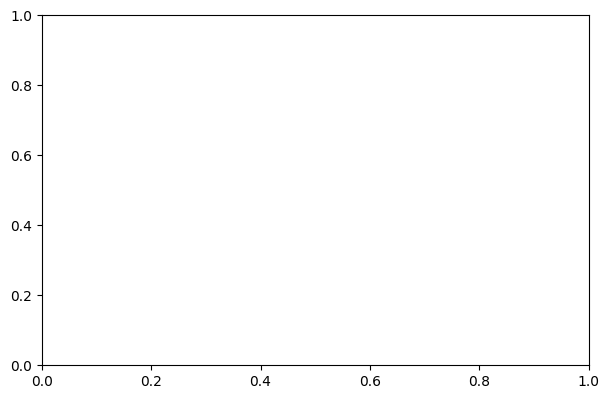

In [12]:
gen_line_charts(metrics, save_path, "training_metrics_graph.png", ["train_", "val_"])